
# 15 - OLS equation and coefficients audit

Methodological audit notebook.

Question:

> What OLS equation are we actually estimating?

Experiments inspected:

1. `ols_core`
2. `ols_core_aglo_fe`
3. `ols_core_year_plus_quarter_fe`

This notebook audits:

- original feature columns entering each experiment
- feature blocks and fixed-effect declarations from YAML snapshots
- variable types in the processed modeling dataset
- post-transform coefficient tables when available
- coefficient magnitudes by scientific family
- top coefficients and FE coefficients

The goal is not causal interpretation. Coefficients belong to the transformed design matrix: standardized numeric columns, binary columns, one-hot categorical columns, and one-hot fixed-effect columns.


## 00. Setup and run discovery

In [15]:

from pathlib import Path
import json
import yaml
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


ROOT_CANDIDATES = [
    Path.cwd(),
    Path.cwd().parent,
    Path("/home/matias/repos/income-modeling-eph"),
]

ROOT = next(
    (p for p in ROOT_CANDIDATES if (p / "reports" / "runs").exists()),
    Path("/home/matias/repos/income-modeling-eph"),
)

RUNS_DIR = ROOT / "reports" / "runs"
DATASET_PATH = ROOT / "data" / "processed" / "modeling_dataset.parquet"
FEATURE_CONTRACT_PATH = ROOT / "configs" / "feature_contract.yaml"

OUTPUT_DIR = ROOT / "reports" / "notebook_outputs" / "ols_equation_and_coefficients"
TABLE_DIR = OUTPUT_DIR / "tables"
FIG_DIR = OUTPUT_DIR / "figures"

TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 180)
pd.set_option("display.max_rows", 180)

print("ROOT:", ROOT)
print("RUNS_DIR:", RUNS_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)


def read_json_if_exists(path: Path):
    if not path.exists():
        return None
    return json.loads(path.read_text())


def read_yaml_if_exists(path: Path):
    if not path.exists():
        return None
    return yaml.safe_load(path.read_text())


def read_csv_if_exists(path: Path) -> pd.DataFrame:
    return pd.read_csv(path) if path.exists() else pd.DataFrame()


RUN_PATTERNS = {
    "ols_core": "ols_core_*",
    "ols_core_aglo_fe": "ols_core_aglo_fe_*",
    "ols_core_year_plus_quarter_fe": "ols_core_year_plus_quarter_fe_*",
}

ORDER = [
    "ols_core",
    "ols_core_aglo_fe",
    "ols_core_year_plus_quarter_fe",
]

DISPLAY_LABELS = {
    "ols_core": "Core OLS",
    "ols_core_aglo_fe": "+ Aglomerado FE",
    "ols_core_year_plus_quarter_fe": "+ Year + Quarter FE",
}


def discover_runs() -> dict[str, Path | None]:
    runs = {}
    for experiment, pattern in RUN_PATTERNS.items():
        candidates = sorted(RUNS_DIR.glob(pattern), key=lambda p: p.name)
        if not candidates:
            runs[experiment] = None
            continue

        exact = []
        for candidate in candidates:
            config = read_yaml_if_exists(candidate / "config_used.yaml") or {}
            experiment_id = ((config.get("experiment") or {}).get("id"))
            if experiment_id == experiment:
                exact.append(candidate)

        runs[experiment] = exact[-1] if exact else candidates[-1]
    return runs


RUNS = discover_runs()

run_table = pd.DataFrame(
    [
        {"experiment": exp, "run_dir": str(path) if path else None, "found": path is not None}
        for exp, path in RUNS.items()
    ]
)

run_table


ROOT: /home/matias/repos/income-modeling-eph
RUNS_DIR: /home/matias/repos/income-modeling-eph/reports/runs
OUTPUT_DIR: /home/matias/repos/income-modeling-eph/reports/notebook_outputs/ols_equation_and_coefficients


,experiment,run_dir,found
0,ols_core,/home/matias/repos/income-modeling-eph/reports...,True
1,ols_core_aglo_fe,/home/matias/repos/income-modeling-eph/reports...,True
2,ols_core_year_plus_quarter_fe,/home/matias/repos/income-modeling-eph/reports...,True


## 01. Load config, feature contract, and run metadata

In [16]:

feature_contract = read_yaml_if_exists(FEATURE_CONTRACT_PATH) or {}

def load_run_metadata(run_dir: Path, experiment: str) -> dict:
    feature_columns = read_json_if_exists(run_dir / "feature_columns.json") or []
    dataset_card = read_json_if_exists(run_dir / "dataset_card.json") or {}
    config_used = read_yaml_if_exists(run_dir / "config_used.yaml") or {}
    feature_view = config_used.get("feature_view") or {}
    model_design = config_used.get("model_design") or {}
    fixed_effects = model_design.get("fixed_effects") or {}
    diagnostics_plan = read_json_if_exists(run_dir / "diagnostics" / "diagnostics_plan.json") or {}
    return {
        "experiment": experiment,
        "label": DISPLAY_LABELS.get(experiment, experiment),
        "run_dir": str(run_dir),
        "feature_columns": feature_columns,
        "n_feature_columns": len(feature_columns),
        "feature_view_name": feature_view.get("name"),
        "include_blocks": feature_view.get("include_blocks"),
        "fixed_effects_config": fixed_effects,
        "dataset_card": dataset_card,
        "config_used": config_used,
        "diagnostics_plan": diagnostics_plan,
    }

metadata_rows = []
for experiment, run_dir in RUNS.items():
    if run_dir is None:
        continue
    metadata_rows.append(load_run_metadata(run_dir, experiment))

run_metadata = pd.DataFrame(metadata_rows)

if run_metadata.empty:
    raise RuntimeError("No runs found. Run the selected OLS experiments first or check RUN_PATTERNS.")

run_metadata[["experiment", "feature_view_name", "include_blocks", "fixed_effects_config", "n_feature_columns"]]


,experiment,feature_view_name,include_blocks,fixed_effects_config,n_feature_columns
0,ols_core,ols_core,"[demographic, education, labor, housing_househ...",{},21
1,ols_core_aglo_fe,ols_core_aglo_fe,"[demographic, education, labor, housing_househ...","[{'name': 'aglo_fe', 'columns': ['AGLOMERADO']...",22
2,ols_core_year_plus_quarter_fe,ols_core_year_plus_quarter_fe,"[demographic, education, labor, housing_househ...","[{'name': 'year_fe', 'columns': ['ANO4'], 'max...",23


## 02. Feature-block registry from contract

In [17]:

def flatten_feature_blocks(contract: dict) -> pd.DataFrame:
    blocks = contract.get("feature_blocks") or {}
    rows = []
    for block_name, spec in blocks.items():
        if not isinstance(spec, dict):
            continue
        for declared_type in ["numeric", "binary", "categorical", "columns"]:
            for col in spec.get(declared_type, []) or []:
                rows.append({
                    "feature_block": block_name,
                    "declared_type": declared_type,
                    "column": str(col),
                })
    return pd.DataFrame(rows)

feature_block_registry = flatten_feature_blocks(feature_contract)
feature_block_registry.to_csv(TABLE_DIR / "T1_feature_block_registry.csv", index=False)
feature_block_registry


,feature_block,declared_type,column
0,demographic,numeric,P03
1,demographic,categorical,P02
2,demographic,categorical,CH07
3,education,categorical,P09
4,education,categorical,P10
5,education,categorical,Max_Nivel_Educativo
6,labor,categorical,CAT_INAC
7,labor,categorical,CAT_OCUP
8,labor,categorical,CONDACT
9,labor,categorical,PP07G_59


## 03. Dataset dtype and cardinality audit

In [ ]:

# Load only columns that appear in inspected runs, plus target/meta if available.
all_feature_columns = sorted(set().union(*run_metadata["feature_columns"].tolist()))
cols_to_load = [c for c in ["row_id", "logP47T", "split"] + all_feature_columns if c]

if not DATASET_PATH.exists():
    raise FileNotFoundError(f"Processed dataset not found: {DATASET_PATH}")

# Avoid failing if some metadata columns are not in parquet.
import pyarrow.parquet as pq
available_cols = set(pq.read_schema(DATASET_PATH).names)
cols_to_load = [c for c in cols_to_load if c in available_cols]

dataset_sample = pd.read_parquet(DATASET_PATH, columns=cols_to_load)

def example_values(s, n=8):
    vals = s.dropna().unique()[:n]
    return [str(v) for v in vals]

def classify_observed_series(s: pd.Series) -> str:
    nonnull = s.dropna()
    if s.name in {"row_id", "split"}:
        return "meta"
    if s.name == "logP47T":
        return "target"
    if len(nonnull) == 0:
        return "empty"
    unique = set(nonnull.unique())
    if nonnull.nunique() <= 2 and unique.issubset({0, 1, 0.0, 1.0, True, False}):
        return "binary_01_observed"
    if pd.api.types.is_bool_dtype(s):
        return "binary_bool_observed"
    if pd.api.types.is_numeric_dtype(s):
        return "numeric_observed"
    return "categorical_observed"

dtype_audit = pd.DataFrame([
    {
        "column": col,
        "dtype": str(dataset_sample[col].dtype),
        "n_unique": dataset_sample[col].nunique(dropna=True),
        "observed_type": classify_observed_series(dataset_sample[col]),
        "examples": example_values(dataset_sample[col]),
    }
    for col in dataset_sample.columns
])

dtype_audit = dtype_audit.merge(
    feature_block_registry,
    on="column",
    how="left"
)

# Columns generated as FE by the experiment may not be in dataset_sample.
dtype_audit.to_csv(TABLE_DIR / "T2_dataset_dtype_cardinality_audit.csv", index=False)

dtype_audit.sort_values(["feature_block", "declared_type", "column"]).head(100)


## 04. Feature inventory by experiment

In [5]:

def feature_inventory_for_experiment(row: pd.Series) -> pd.DataFrame:
    experiment = row["experiment"]
    feature_columns = row["feature_columns"]
    fe_specs = row["fixed_effects_config"] or []
    if not isinstance(fe_specs, list):
        fe_specs = []
    fe_generated = {f"fe_{str(spec.get('name'))}" for spec in fe_specs if isinstance(spec, dict)}
    fe_sources = set()
    for spec in fe_specs:
        if isinstance(spec, dict):
            fe_sources.update(str(c) for c in (spec.get("columns") or []))

    rows = []
    for col in feature_columns:
        block_rows = feature_block_registry.query("column == @col")
        declared_blocks = sorted(block_rows["feature_block"].dropna().unique().tolist())
        declared_types = sorted(block_rows["declared_type"].dropna().unique().tolist())

        dtype_row = dtype_audit.query("column == @col")
        dtype = dtype_row["dtype"].iloc[0] if not dtype_row.empty else None
        observed_type = dtype_row["observed_type"].iloc[0] if not dtype_row.empty else None
        n_unique = dtype_row["n_unique"].iloc[0] if not dtype_row.empty else np.nan

        is_fe = col.startswith("fe_") or col in fe_generated
        rows.append({
            "experiment": experiment,
            "feature_column": col,
            "is_fixed_effect_column": is_fe,
            "is_fe_source_column": col in fe_sources,
            "feature_blocks": ", ".join(declared_blocks),
            "declared_types": ", ".join(declared_types),
            "dtype": dtype,
            "observed_type": observed_type,
            "n_unique": n_unique,
        })
    return pd.DataFrame(rows)

feature_inventory = pd.concat(
    [feature_inventory_for_experiment(row) for _, row in run_metadata.iterrows()],
    ignore_index=True,
)

def canonical_family(row):
    col = row["feature_column"]
    if row["is_fixed_effect_column"] or col.startswith("fe_"):
        return "fixed_effect"
    blocks = str(row["feature_blocks"])
    if blocks and blocks != "nan":
        # Prefer first declared block for compact summaries.
        return blocks.split(", ")[0]
    if row["observed_type"] in {"binary_01_observed", "binary_bool_observed"}:
        return "binary_unregistered"
    if row["observed_type"] == "numeric_observed":
        return "numeric_unregistered"
    if row["observed_type"] == "categorical_observed":
        return "categorical_unregistered"
    return "other_unregistered"

feature_inventory["canonical_family"] = feature_inventory.apply(canonical_family, axis=1)

feature_inventory.to_csv(TABLE_DIR / "T3_feature_inventory_by_experiment.csv", index=False)

feature_inventory_summary = (
    feature_inventory
    .groupby(["experiment", "canonical_family"], as_index=False)
    .agg(
        n_original_columns=("feature_column", "nunique"),
        columns=("feature_column", lambda s: ", ".join(sorted(s.unique())[:20])),
    )
)

feature_inventory_summary.to_csv(TABLE_DIR / "T4_feature_inventory_summary.csv", index=False)

display(feature_inventory_summary)


,experiment,canonical_family,n_original_columns,columns
0,ols_core,demographic,3,"CH07, P02, P03"
1,ols_core,education,3,"Max_Nivel_Educativo, P09, P10"
2,ols_core,housing_household,11,"H05, H06, H07, H08, H09, H13, H14, IX_TOT, PRO..."
3,ols_core,labor,4,"CAT_INAC, CAT_OCUP, CONDACT, PP07G_59"
4,ols_core_aglo_fe,demographic,3,"CH07, P02, P03"
5,ols_core_aglo_fe,education,3,"Max_Nivel_Educativo, P09, P10"
6,ols_core_aglo_fe,fixed_effect,1,fe_aglo_fe
7,ols_core_aglo_fe,housing_household,11,"H05, H06, H07, H08, H09, H13, H14, IX_TOT, PRO..."
8,ols_core_aglo_fe,labor,4,"CAT_INAC, CAT_OCUP, CONDACT, PP07G_59"
9,ols_core_year_plus_quarter_fe,demographic,3,"CH07, P02, P03"


## 05. Load coefficient artifacts

In [6]:

def find_coefficient_files(run_dir: Path) -> list[Path]:
    diagnostics_dir = run_dir / "diagnostics"
    if not diagnostics_dir.exists():
        return []
    patterns = [
        "*LinearRegression*coefficients*.csv",
        "*linear*coefficients*.csv",
        "*best_coefficients*.csv",
        "*fixed_effect*coefficients*.csv",
        "*fe*coefficients*.csv",
    ]
    files = []
    for pattern in patterns:
        files.extend(diagnostics_dir.glob(pattern))
    return sorted(set(files))

coef_parts = []

for experiment, run_dir in RUNS.items():
    if run_dir is None:
        continue
    for path in find_coefficient_files(run_dir):
        df = pd.read_csv(path)
        df["experiment"] = experiment
        df["source_file"] = str(path.relative_to(run_dir))
        coef_parts.append(df)

coefficients_raw = pd.concat(coef_parts, ignore_index=True) if coef_parts else pd.DataFrame()

if coefficients_raw.empty:
    print("No coefficient files found in diagnostics/.")
else:
    print(coefficients_raw.shape)
    display(coefficients_raw.head())
    coefficients_raw.to_csv(TABLE_DIR / "T5_coefficients_raw_all_files.csv", index=False)


(316, 14)


,run_id,model,abs_rank,feature,coefficient,abs_coefficient,experiment,source_file,fe_name,level,income_factor,pct_change,sign,rank
0,ols_core_20260611T084128Z,LinearRegression,1.0,cat__CONDACT_3,-0.558844,0.558844,ols_core,diagnostics/LinearRegression_best_coefficients...,NaN,NaN,NaN,NaN,NaN,NaN
1,ols_core_20260611T084128Z,LinearRegression,2.0,cat__CONDACT_2,-0.491722,0.491722,ols_core,diagnostics/LinearRegression_best_coefficients...,NaN,NaN,NaN,NaN,NaN,NaN
2,ols_core_20260611T084128Z,LinearRegression,3.0,cat__CONDACT_9,-0.398681,0.398681,ols_core,diagnostics/LinearRegression_best_coefficients...,NaN,NaN,NaN,NaN,NaN,NaN
3,ols_core_20260611T084128Z,LinearRegression,4.0,cat__CAT_INAC_1,0.389331,0.389331,ols_core,diagnostics/LinearRegression_best_coefficients...,NaN,NaN,NaN,NaN,NaN,NaN
4,ols_core_20260611T084128Z,LinearRegression,5.0,cat__CAT_OCUP_4,-0.385263,0.385263,ols_core,diagnostics/LinearRegression_best_coefficients...,NaN,NaN,NaN,NaN,NaN,NaN



## 06. Normalize coefficient table

Different backend versions may use slightly different coefficient column names. This cell normalizes the most common variants into:

```text
experiment
feature
coef
abs_coef
source_file
family
```


In [7]:

def first_existing(cols, candidates):
    for c in candidates:
        if c in cols:
            return c
    return None

def normalize_coefficients(df: pd.DataFrame) -> pd.DataFrame:
    if df.empty:
        return pd.DataFrame(columns=["experiment", "feature", "coef", "abs_coef", "source_file"])

    feature_col = first_existing(df.columns, ["feature", "feature_name", "term", "coefficient_name", "column"])
    coef_col = first_existing(df.columns, ["coef", "coefficient", "estimate", "value"])
    if feature_col is None or coef_col is None:
        print("Could not infer feature/coef columns. Available columns:", df.columns.tolist())
        return pd.DataFrame(columns=["experiment", "feature", "coef", "abs_coef", "source_file"])

    out = df[["experiment", "source_file", feature_col, coef_col]].copy()
    out = out.rename(columns={feature_col: "feature", coef_col: "coef"})
    out["coef"] = pd.to_numeric(out["coef"], errors="coerce")
    out = out.dropna(subset=["feature", "coef"])
    out["feature"] = out["feature"].astype(str)
    out["abs_coef"] = out["coef"].abs()
    return out

coefficients = normalize_coefficients(coefficients_raw)

# Helpers to parse sklearn ColumnTransformer names.
def strip_transformer_prefix(feature: str) -> str:
    # examples: num__P03, cat__P09_3, remainder__x
    if "__" in feature:
        return feature.split("__", 1)[1]
    return feature

def base_feature_from_transformed(feature: str) -> str:
    f = strip_transformer_prefix(feature)
    if f.startswith("fe_"):
        return f
    # For one-hot encoded columns, sklearn often emits COLUMN_category.
    # Recover by longest known original feature prefix.
    known = sorted(set(feature_inventory["feature_column"]), key=len, reverse=True)
    for col in known:
        if f == col or f.startswith(col + "_"):
            return col
    return f

def family_from_feature(feature: str) -> str:
    base = base_feature_from_transformed(feature)
    if base.startswith("fe_"):
        return "fixed_effect"
    matches = feature_block_registry.query("column == @base")
    if not matches.empty:
        return str(matches["feature_block"].iloc[0])
    if feature.startswith("num__"):
        return "numeric_unregistered"
    if feature.startswith("bin__"):
        return "binary_unregistered"
    if feature.startswith("cat__"):
        return "categorical_unregistered"
    return "other_unregistered"

if not coefficients.empty:
    coefficients["base_feature"] = coefficients["feature"].map(base_feature_from_transformed)
    coefficients["family"] = coefficients["feature"].map(family_from_feature)
    coefficients["is_fixed_effect"] = coefficients["family"].eq("fixed_effect")
    coefficients.to_csv(TABLE_DIR / "T6_coefficients_normalized.csv", index=False)
    display(coefficients.head())
else:
    print("No normalized coefficients available.")


,experiment,source_file,feature,coef,abs_coef,base_feature,family,is_fixed_effect
0,ols_core,diagnostics/LinearRegression_best_coefficients...,cat__CONDACT_3,-0.558844,0.558844,CONDACT,labor,False
1,ols_core,diagnostics/LinearRegression_best_coefficients...,cat__CONDACT_2,-0.491722,0.491722,CONDACT,labor,False
2,ols_core,diagnostics/LinearRegression_best_coefficients...,cat__CONDACT_9,-0.398681,0.398681,CONDACT,labor,False
3,ols_core,diagnostics/LinearRegression_best_coefficients...,cat__CAT_INAC_1,0.389331,0.389331,CAT_INAC,labor,False
4,ols_core,diagnostics/LinearRegression_best_coefficients...,cat__CAT_OCUP_4,-0.385263,0.385263,CAT_OCUP,labor,False


## 07. Post-transform matrix audit

In [8]:

if coefficients.empty:
    post_transform_audit = feature_inventory_summary.copy()
    post_transform_audit["n_transformed_coefs"] = np.nan
    post_transform_audit["note"] = "Coefficient artifacts not found; only original feature columns counted."
else:
    post_transform_audit = (
        coefficients
        .groupby(["experiment", "family"], as_index=False)
        .agg(
            n_transformed_coefs=("feature", "nunique"),
            mean_abs_coef=("abs_coef", "mean"),
            median_abs_coef=("abs_coef", "median"),
            max_abs_coef=("abs_coef", "max"),
        )
        .rename(columns={"family": "canonical_family"})
    )
    post_transform_audit = post_transform_audit.merge(
        feature_inventory_summary[["experiment", "canonical_family", "n_original_columns"]],
        on=["experiment", "canonical_family"],
        how="outer",
    )

post_transform_audit = post_transform_audit.sort_values(["experiment", "canonical_family"])
post_transform_audit.to_csv(TABLE_DIR / "T7_post_transform_matrix_audit.csv", index=False)
post_transform_audit.round(5)


,experiment,canonical_family,n_transformed_coefs,mean_abs_coef,median_abs_coef,max_abs_coef,n_original_columns
0,ols_core,demographic,6,0.04868,0.05969,0.09076,3
1,ols_core,education,20,0.07550,0.05258,0.22499,3
2,ols_core,housing_household,39,0.03083,0.01489,0.27645,11
3,ols_core,labor,15,0.26839,0.22812,0.55884,4
4,ols_core_aglo_fe,demographic,6,0.04933,0.05988,0.09114,3
5,ols_core_aglo_fe,education,20,0.08039,0.06742,0.21450,3
6,ols_core_aglo_fe,fixed_effect,32,0.03938,0.02421,0.14889,1
7,ols_core_aglo_fe,housing_household,39,0.02929,0.01482,0.27112,11
8,ols_core_aglo_fe,labor,15,0.27115,0.23845,0.56991,4
9,ols_core_year_plus_quarter_fe,demographic,6,0.04899,0.06019,0.09112,3


## 08. Figure 1 — original feature inventory

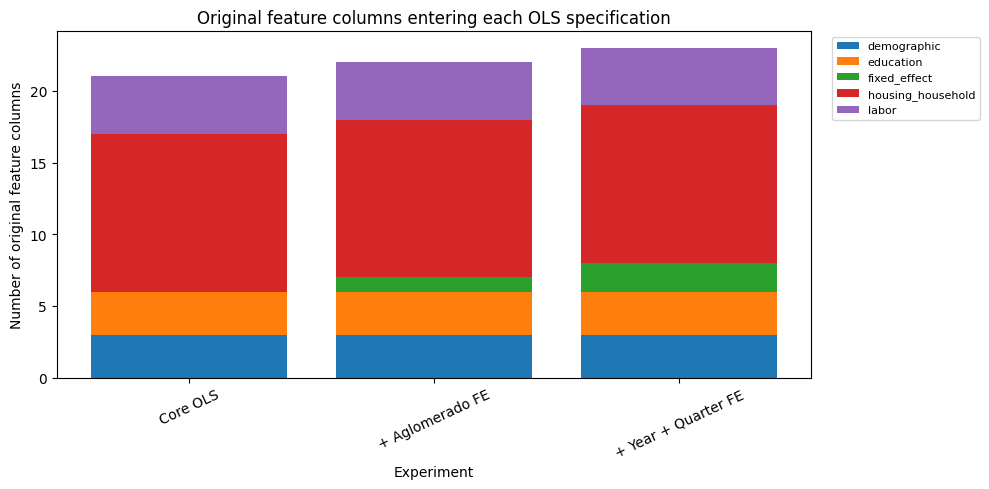

In [9]:

plot_df = feature_inventory_summary.copy()

fig, ax = plt.subplots(figsize=(10, 5))
families = sorted(plot_df["canonical_family"].unique())
experiments = ORDER
x = np.arange(len(experiments))
bottom = np.zeros(len(experiments))

for family in families:
    vals = []
    for exp in experiments:
        row = plot_df.query("experiment == @exp and canonical_family == @family")
        vals.append(float(row["n_original_columns"].iloc[0]) if not row.empty else 0.0)
    ax.bar([DISPLAY_LABELS.get(e, e) for e in experiments], vals, bottom=bottom, label=family)
    bottom += np.asarray(vals)

ax.set_title("Original feature columns entering each OLS specification")
ax.set_xlabel("Experiment")
ax.set_ylabel("Number of original feature columns")
ax.tick_params(axis="x", rotation=25)
ax.legend(fontsize=8, bbox_to_anchor=(1.02, 1), loc="upper left")
fig.tight_layout()
fig.savefig(FIG_DIR / "F1_ols_equation_original_feature_inventory.png", dpi=160)
plt.show()


## 09. Figure 2 — top absolute coefficients

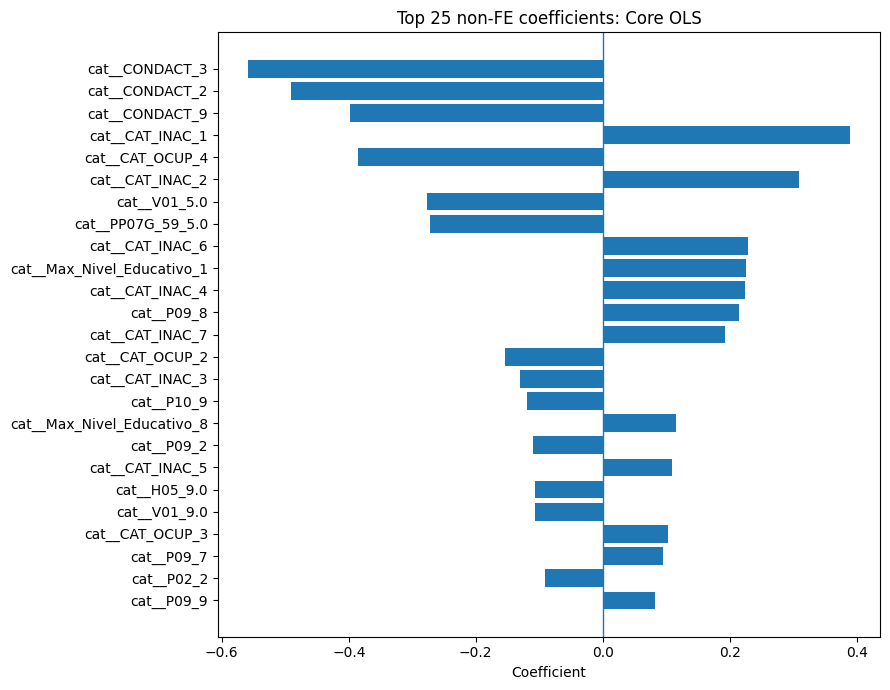

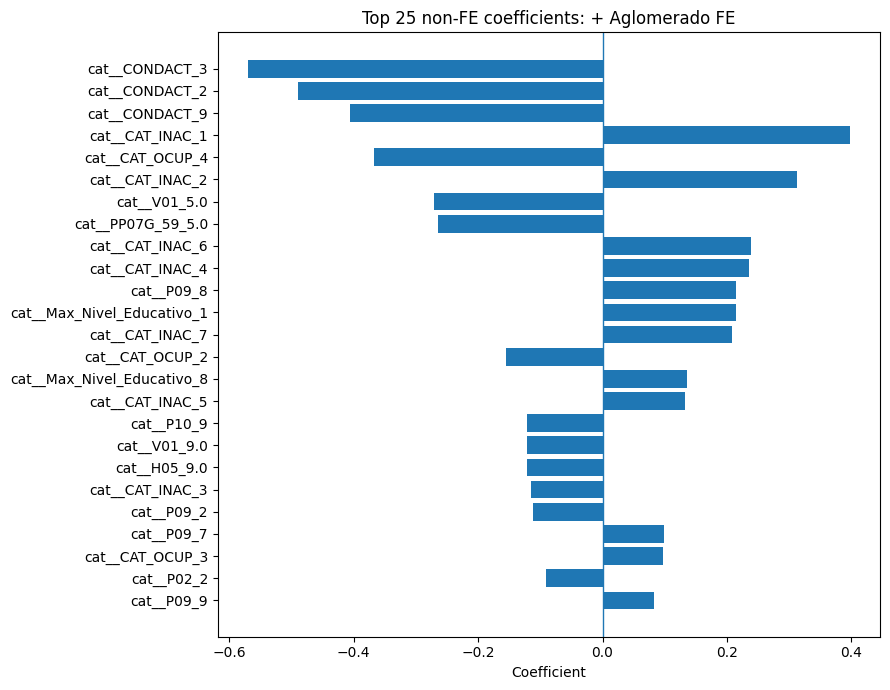

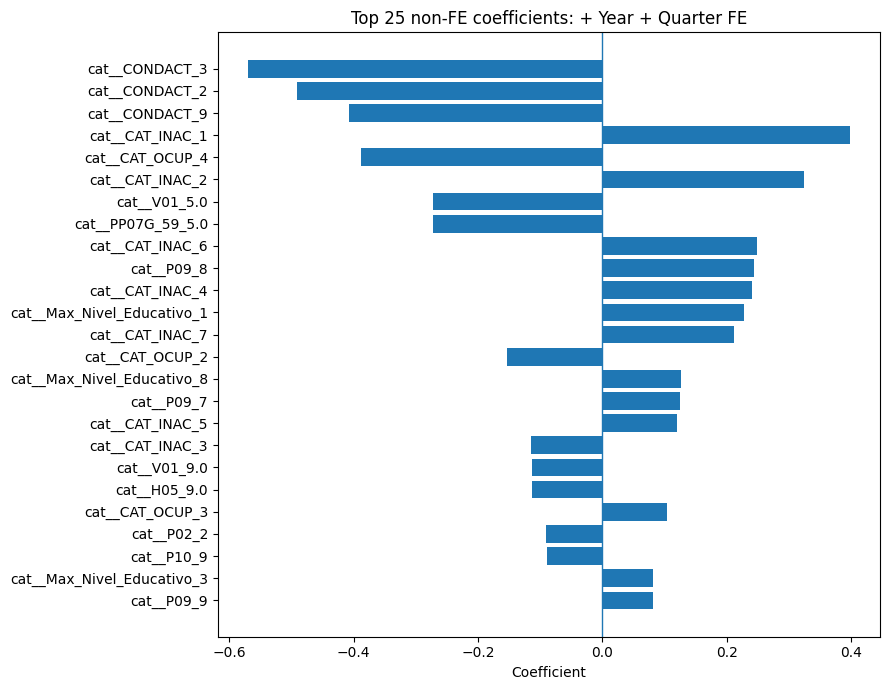

In [10]:

if coefficients.empty:
    print("Skipping coefficient plots: no coefficient artifacts found.")
else:
    TOP_N = 25
    for experiment in ORDER:
        tmp = (
            coefficients
            .query("experiment == @experiment and not is_fixed_effect")
            .sort_values("abs_coef", ascending=False)
            .head(TOP_N)
            .copy()
        )
        if tmp.empty:
            continue

        tmp = tmp.sort_values("abs_coef")
        fig, ax = plt.subplots(figsize=(9, 7))
        ax.barh(tmp["feature"], tmp["coef"])
        ax.axvline(0, linewidth=1)
        ax.set_title(f"Top {TOP_N} non-FE coefficients: {DISPLAY_LABELS.get(experiment, experiment)}")
        ax.set_xlabel("Coefficient")
        fig.tight_layout()
        fig.savefig(FIG_DIR / f"F2_top_coefficients_{experiment}.png", dpi=160)
        plt.show()


## 10. Figure 3 — coefficient magnitudes by family

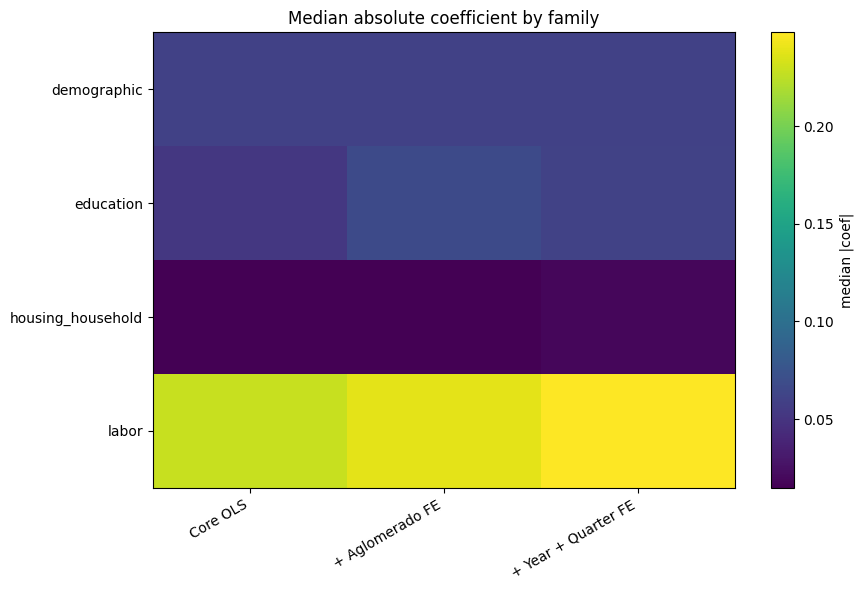

,experiment,family,n,mean_abs_coef,median_abs_coef,p90_abs_coef,max_abs_coef
3,ols_core,labor,15,0.26839,0.22812,0.45451,0.55884
0,ols_core,demographic,6,0.04868,0.05969,0.08043,0.09076
1,ols_core,education,20,0.07550,0.05258,0.12935,0.22499
2,ols_core,housing_household,39,0.03083,0.01489,0.05557,0.27645
7,ols_core_aglo_fe,labor,15,0.27115,0.23845,0.45567,0.56991
5,ols_core_aglo_fe,education,20,0.08039,0.06742,0.14424,0.21450
4,ols_core_aglo_fe,demographic,6,0.04933,0.05988,0.08142,0.09114
6,ols_core_aglo_fe,housing_household,39,0.02929,0.01482,0.04910,0.27112
11,ols_core_year_plus_quarter_fe,labor,15,0.27489,0.24800,0.45777,0.56977
9,ols_core_year_plus_quarter_fe,education,20,0.08023,0.06095,0.13614,0.24309


In [11]:

if coefficients.empty:
    print("Skipping coefficient-family plot: no coefficient artifacts found.")
else:
    coef_family_summary = (
        coefficients
        .query("not is_fixed_effect")
        .groupby(["experiment", "family"], as_index=False)
        .agg(
            n=("feature", "nunique"),
            mean_abs_coef=("abs_coef", "mean"),
            median_abs_coef=("abs_coef", "median"),
            p90_abs_coef=("abs_coef", lambda s: s.quantile(0.90)),
            max_abs_coef=("abs_coef", "max"),
        )
    )
    coef_family_summary.to_csv(TABLE_DIR / "T8_coefficient_family_summary.csv", index=False)

    plot_df = coef_family_summary.copy()
    pivot = plot_df.pivot_table(
        index="family",
        columns="experiment",
        values="median_abs_coef",
        aggfunc="first",
    ).reindex(columns=[e for e in ORDER if e in plot_df["experiment"].unique()])

    fig, ax = plt.subplots(figsize=(9, 6))
    im = ax.imshow(pivot.fillna(0).to_numpy(), aspect="auto")
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index)
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels([DISPLAY_LABELS.get(c, c) for c in pivot.columns], rotation=30, ha="right")
    ax.set_title("Median absolute coefficient by family")
    fig.colorbar(im, ax=ax, label="median |coef|")
    fig.tight_layout()
    fig.savefig(FIG_DIR / "F3_coefficient_median_abs_by_family.png", dpi=160)
    plt.show()

    display(coef_family_summary.sort_values(["experiment", "median_abs_coef"], ascending=[True, False]).round(5))


## 11. Fixed-effect coefficient audit

,experiment,n_fe_coefs,mean_abs_fe,median_abs_fe,p90_abs_fe,max_abs_fe
0,ols_core_aglo_fe,32,0.03938,0.02421,0.09023,0.14889
1,ols_core_year_plus_quarter_fe,6,0.02625,0.01645,0.06022,0.06167


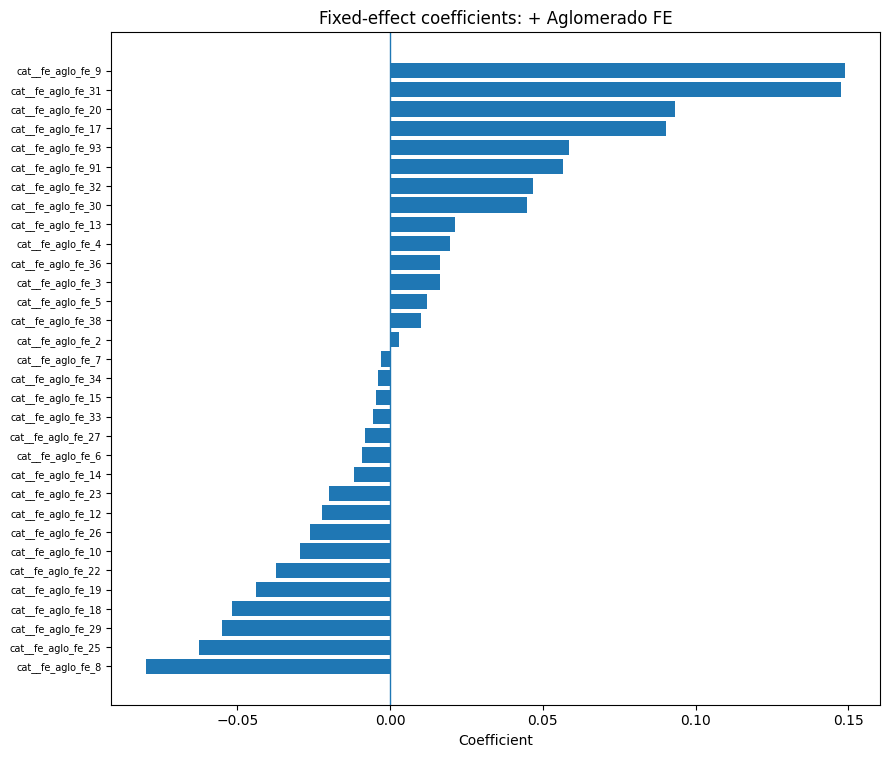

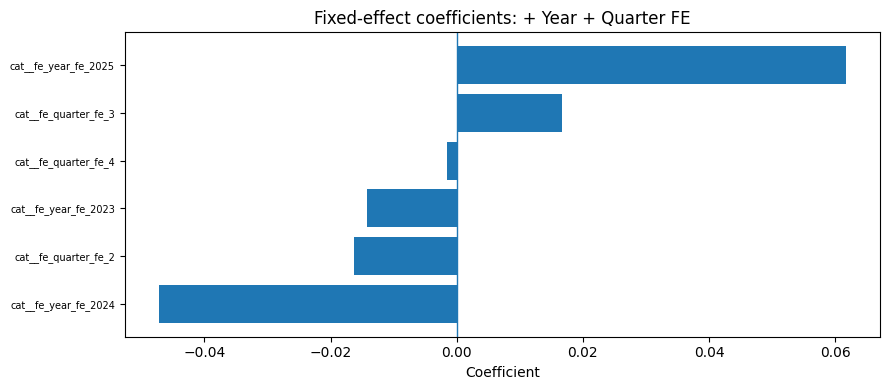

In [12]:

if coefficients.empty:
    print("Skipping FE coefficient audit: no coefficient artifacts found.")
else:
    fe_coefs = coefficients.query("is_fixed_effect").copy()
    fe_coefs.to_csv(TABLE_DIR / "T9_fixed_effect_coefficients_normalized.csv", index=False)

    if fe_coefs.empty:
        print("No fixed-effect coefficients found in coefficient artifacts.")
    else:
        fe_summary = (
            fe_coefs
            .groupby("experiment", as_index=False)
            .agg(
                n_fe_coefs=("feature", "nunique"),
                mean_abs_fe=("abs_coef", "mean"),
                median_abs_fe=("abs_coef", "median"),
                p90_abs_fe=("abs_coef", lambda s: s.quantile(0.90)),
                max_abs_fe=("abs_coef", "max"),
            )
        )
        fe_summary.to_csv(TABLE_DIR / "T10_fixed_effect_coefficient_summary.csv", index=False)
        display(fe_summary.round(5))

        for experiment in fe_coefs["experiment"].unique():
            tmp = (
                fe_coefs
                .query("experiment == @experiment")
                .sort_values("coef")
                .copy()
            )
            if tmp.empty:
                continue
            fig, ax = plt.subplots(figsize=(9, max(4, min(12, len(tmp) * 0.12))))
            ax.barh(tmp["feature"], tmp["coef"])
            ax.axvline(0, linewidth=1)
            ax.set_title(f"Fixed-effect coefficients: {DISPLAY_LABELS.get(experiment, experiment)}")
            ax.set_xlabel("Coefficient")
            ax.tick_params(axis="y", labelsize=7)
            fig.tight_layout()
            fig.savefig(FIG_DIR / f"F4_fixed_effect_coefficients_{experiment}.png", dpi=160)
            plt.show()


## 12. Equation statement helper

In [13]:

def equation_statement(row: pd.Series) -> str:
    exp = row["experiment"]
    blocks = row.get("include_blocks") or []
    fe_specs = row.get("fixed_effects_config") or []
    if not isinstance(fe_specs, list):
        fe_specs = []
    fe_terms = []
    for spec in fe_specs:
        if not isinstance(spec, dict):
            continue
        cols = spec.get("columns") or []
        name = spec.get("name")
        fe_terms.append(f"{name}: " + " + ".join(cols))

    block_text = ", ".join(blocks) if blocks else "all/default columns"
    fe_text = "; ".join(fe_terms) if fe_terms else "none"

    return (
        f"{exp}: y_i = α + X_i β"
        + (" + FE_i δ" if fe_terms else "")
        + " + ε_i. "
        f"Feature blocks: {block_text}. Fixed effects: {fe_text}."
    )

equation_statements = pd.DataFrame({
    "experiment": run_metadata["experiment"],
    "equation_statement": run_metadata.apply(equation_statement, axis=1),
})

equation_statements.to_csv(TABLE_DIR / "T11_equation_statements.csv", index=False)

for stmt in equation_statements["equation_statement"]:
    print("-", stmt)


- ols_core: y_i = α + X_i β + ε_i. Feature blocks: demographic, education, labor, housing_household. Fixed effects: none.
- ols_core_aglo_fe: y_i = α + X_i β + FE_i δ + ε_i. Feature blocks: demographic, education, labor, housing_household. Fixed effects: aglo_fe: AGLOMERADO.
- ols_core_year_plus_quarter_fe: y_i = α + X_i β + FE_i δ + ε_i. Feature blocks: demographic, education, labor, housing_household. Fixed effects: year_fe: ANO4; quarter_fe: TRIMESTRE.


## 13. Automatic diagnostic summary

In [14]:

notes = []

for _, row in run_metadata.iterrows():
    notes.append(
        f"{row['experiment']}: {row['n_feature_columns']} original feature columns; "
        f"include_blocks={row['include_blocks']}; fixed_effects={row['fixed_effects_config']}."
    )

if not coefficients.empty:
    for exp in ORDER:
        tmp = coefficients.query("experiment == @exp")
        if tmp.empty:
            continue
        n_coef = tmp["feature"].nunique()
        n_fe = tmp.query("is_fixed_effect")["feature"].nunique()
        top = tmp.sort_values("abs_coef", ascending=False).head(1)
        top_text = (
            f"top |coef|={top['feature'].iloc[0]} ({top['coef'].iloc[0]:.5f})"
            if not top.empty else "top |coef| unavailable"
        )
        notes.append(f"{exp}: {n_coef} transformed coefficients; {n_fe} FE coefficients; {top_text}.")
else:
    notes.append(
        "Coefficient artifacts were not found. The notebook still audits original feature columns and YAML design, "
        "but post-transform coefficient diagnostics require backend coefficient outputs."
    )

DIAGNOSTIC_SUMMARY = "\n".join(f"- {note}" for note in notes)
print(DIAGNOSTIC_SUMMARY)

(TABLE_DIR / "T12_ols_equation_diagnostic_notes.txt").write_text(DIAGNOSTIC_SUMMARY, encoding="utf-8")


- ols_core: 21 original feature columns; include_blocks=['demographic', 'education', 'labor', 'housing_household']; fixed_effects={}.
- ols_core_aglo_fe: 22 original feature columns; include_blocks=['demographic', 'education', 'labor', 'housing_household']; fixed_effects=[{'name': 'aglo_fe', 'columns': ['AGLOMERADO'], 'max_levels': 100, 'drop_first': True, 'drop_source_columns': True}].
- ols_core_year_plus_quarter_fe: 23 original feature columns; include_blocks=['demographic', 'education', 'labor', 'housing_household']; fixed_effects=[{'name': 'year_fe', 'columns': ['ANO4'], 'max_levels': 10, 'drop_first': True, 'drop_source_columns': True}, {'name': 'quarter_fe', 'columns': ['TRIMESTRE'], 'max_levels': 8, 'drop_first': True, 'drop_source_columns': True}].
- ols_core: 80 transformed coefficients; 0 FE coefficients; top |coef|=cat__CONDACT_3 (-0.55884).
- ols_core_aglo_fe: 112 transformed coefficients; 32 FE coefficients; top |coef|=cat__CONDACT_3 (-0.56991).
- ols_core_year_plus_quart

1092


## 14. Outputs written

Tables:

```text
reports/notebook_outputs/ols_equation_and_coefficients/tables/
```

Figures:

```text
reports/notebook_outputs/ols_equation_and_coefficients/figures/
```

Key thesis candidates:

```text
T2_dataset_dtype_cardinality_audit.csv
T3_feature_inventory_by_experiment.csv
T7_post_transform_matrix_audit.csv
T8_coefficient_family_summary.csv
T10_fixed_effect_coefficient_summary.csv
T11_equation_statements.csv
F1_ols_equation_original_feature_inventory.png
F2_top_coefficients_<experiment>.png
F3_coefficient_median_abs_by_family.png
F4_fixed_effect_coefficients_<experiment>.png
```
